# Spectra & validity-gate atlas — λ_min→0 across the whole store

**Purpose.** Programme standard (2026-07-03): every study reports efficiency, false rate
AND the activation spectrum, with the validity gate max|x| ≤ 50 making the λ_min→0
explosion regime measurable. This notebook is the cross-study atlas: the per-study gate
statistics straight from the view's `max_abs_x` column, the Larger_Scatter resonance, the
Larger_Scatter_Density frontier, and the cross-study synthesis.

**Provenance.** qtrk_store metrics view (rebuilt 2026-07-04, 17k+ rows, `max_abs_x`);
per-study streamed-vector gate CSVs from `study_spectra.py` (commit `a3379c18`);
gate convention from Epsilon_study_2 §7.12 / ERF Youden.

In [1]:
import os, sys, time
from pathlib import Path
for p in ("/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/_shared",
          "/data/bfys/gscriven/LHCb_VeLo_Toy_Model/src"):
    if p not in sys.path:
        sys.path.insert(0, p)
os.environ.setdefault("QTRK_STORE", "/data/bfys/gscriven/qtrk_store")
import re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import qtrk_pipeline as qp

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_CLS, C_Q, C_QSVT = "#33322e", "#e34948", "#2a78d6"
FAR_FLOOR = 5e-5   # far=0 rendered as open marker at the floor on log axes

MPATH = Path(os.environ["QTRK_STORE"]) / "manifest" / "metrics.csv"
M = pd.read_csv(MPATH)
print(f"metrics view: {len(M):,} rows, mtime {time.ctime(MPATH.stat().st_mtime)}")
print(M.solver.value_counts().to_string())

def far_plot(ax, x, y, **kw):
    """Plot false rate on a log axis with far=0 as open markers at the floor."""
    y = np.asarray(y, float)
    zero = y <= 0
    ax.plot(x, np.maximum(y, FAR_FLOOR), **kw)
    if zero.any():
        kw2 = {k: v for k, v in kw.items() if k in ("color", "marker")}
        ax.plot(np.asarray(x)[zero], np.full(zero.sum(), FAR_FLOOR),
                ls="none", mfc="white", **kw2)

def study_member(series, name):
    """Exact-token membership on the (possibly multi-study) `studies` column.

    A substring test (`.str.contains(name)`) lets 'Larger_Scatter' swallow every
    'Larger_Scatter_Density' row -- the bug fixed in qtrk_pipeline.load_metrics
    (commit 25df2eba). Split each cell on the separator and test exact membership
    so genuinely shared cells (e.g. rows tagged both Larger_Scatter AND
    Larger_Scatter_Density) are kept, not silently dropped by a `~contains` guard.
    """
    return series.fillna("").astype(str).str.split(r"[|,;\s]+").apply(lambda toks: name in toks)


metrics view: 23,087 rows, mtime Sat Jul  4 21:21:43 2026
solver
classical    14683
quantum       6005
qsvt          2399


## Global gate overview — every study, straight from the view

                        solves  excluded_frac    max_maxabs
study                                                      
Noisy_Density             1280       0.307031  5.849410e+04
ERF                       4320       0.266204  1.272597e+29
Larger_Scatter_Density    1280       0.096875  4.748335e+21
Epsilon_study_2           1920       0.087500  1.601484e+20
Verify_new_results        1870       0.052941  2.394674e+28
QSVT_codesign               33       0.030303  5.469579e+01
Larger_Scatter            3520       0.000000  1.941827e+01
Noisy_Ladder               320       0.000000  9.664594e+00
QSVT_robustness            140       0.000000  1.500002e+00


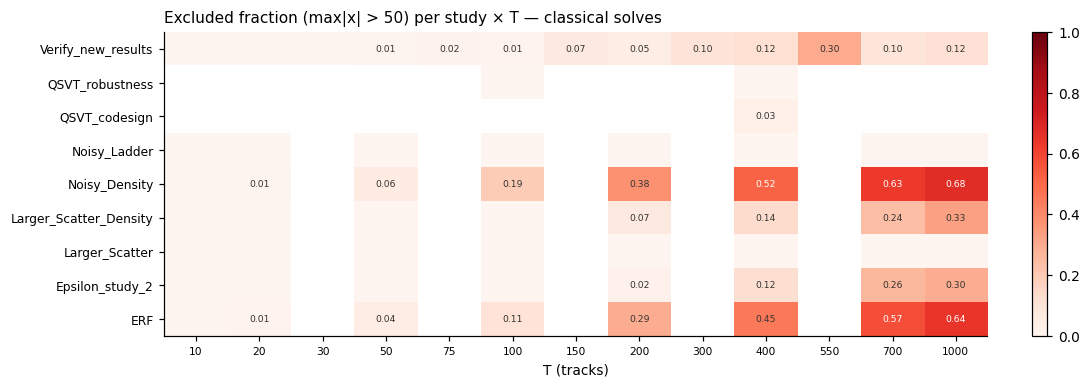

In [2]:
cls = M[M.solver == "classical"].assign(exc=lambda d: d.max_abs_x > 50)
g = cls.groupby("study").agg(solves=("exc", "size"), excluded_frac=("exc", "mean"),
                             max_maxabs=("max_abs_x", "max"))
print(g.sort_values("excluded_frac", ascending=False).to_string())
byT = cls.pivot_table(index="study", columns="n_trk", values="exc", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 3.6))
im = ax.imshow(byT.values, aspect="auto", cmap="Reds", vmin=0, vmax=1, origin="lower")
ax.set_xticks(range(len(byT.columns)), [str(int(t)) for t in byT.columns], fontsize=7)
ax.set_yticks(range(len(byT.index)), byT.index, fontsize=8)
for (i, j), v in np.ndenumerate(byT.values):
    if np.isfinite(v) and v > 0:
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                color="white" if v > 0.5 else "#33322e")
ax.set_xlabel("T (tracks)"); ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.03)
ax.set_title("Excluded fraction (max|x| > 50) per study \u00d7 T \u2014 classical solves",
             loc="left", fontsize=10)
fig.tight_layout(); fig.savefig("figures/sg_nb_global_atlas.png", bbox_inches="tight"); plt.show()

## Larger_Scatter: no σ_scatt resonance — zero explosions (corrected 2026-07-06)

The previously published "σ_scatt ≈ 3e-4 resonance at drop = 0" was **contamination**: a
substring membership filter pulled every Larger_Scatter_Density row into the
Larger_Scatter selection (fixed in `qtrk_pipeline.load_metrics`, commit `25df2eba`).
With exact-token membership the pivot below is identically zero.

n_trk        10    20    50    100   200   400   700   1000
sigma_scatt                                                
0.0001        0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
0.0003        0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
0.0005        0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
0.0007        0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0
0.0010        0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0


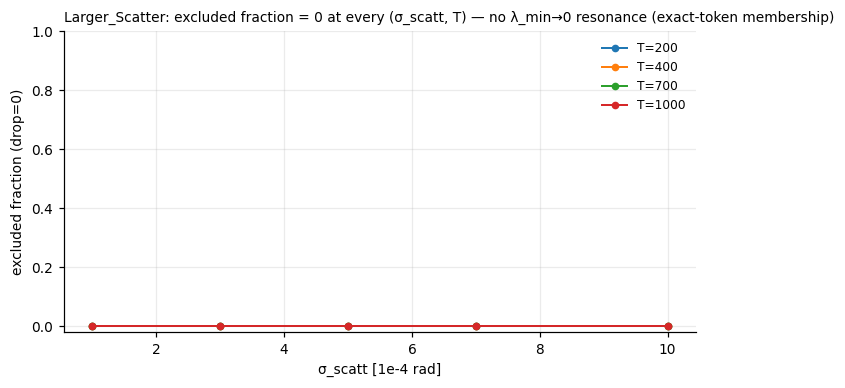

excluded fraction across ALL drop>0 cells: 0.0000  (1% hit inefficiency kills the explosions)
max max|x| across the whole Larger_Scatter grid: 19.4  (gate is 50)


In [3]:
ls = cls[study_member(cls.studies, "Larger_Scatter")]
res = ls[ls.hit_ineff == 0].pivot_table(index="sigma_scatt", columns="n_trk",
                                        values="exc", aggfunc="mean")
print(res.to_string())
fig, ax = plt.subplots(figsize=(6.5, 3.6))
for T in [200, 400, 700, 1000]:
    if T in res.columns:
        ax.plot(res.index * 1e4, res[T], marker="o", ms=4, lw=1.3, label=f"T={T}")
ax.set_ylim(-0.02, 1.0)
ax.set_xlabel("σ_scatt [1e-4 rad]"); ax.set_ylabel("excluded fraction (drop=0)")
ax.legend(fontsize=8)
ax.set_title("Larger_Scatter: excluded fraction = 0 at every (σ_scatt, T) — "
             "no λ_min→0 resonance (exact-token membership)", loc="left", fontsize=9)
fig.tight_layout(); fig.savefig("figures/sg_nb_ls_resonance.png", bbox_inches="tight"); plt.show()
drop = ls[ls.hit_ineff > 0].exc.mean()
print(f"excluded fraction across ALL drop>0 cells: {drop:.4f}  (1% hit inefficiency kills the explosions)")
print(f"max max|x| across the whole Larger_Scatter grid: {ls.max_abs_x.max():.1f}  (gate is 50)")

## Larger_Scatter_Density + Noisy_Density: the density × window frontier

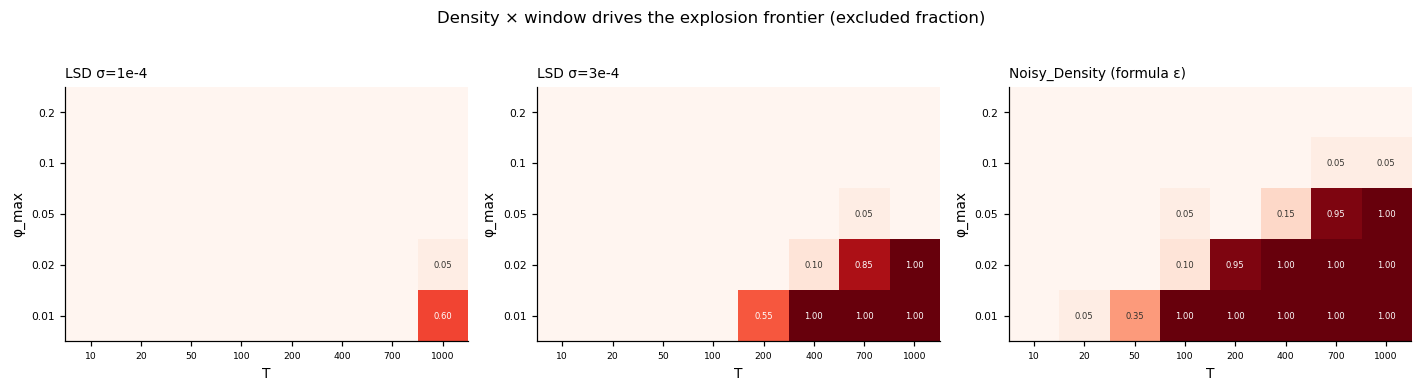

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
panels = [
    ("LSD \u03c3=1e-4", cls[study_member(cls.studies, "Larger_Scatter_Density")
                        & np.isclose(cls.sigma_scatt, 1e-4)]),
    ("LSD \u03c3=3e-4", cls[study_member(cls.studies, "Larger_Scatter_Density")
                        & np.isclose(cls.sigma_scatt, 3e-4)]),
    ("Noisy_Density (formula \u03b5)", cls[study_member(cls.studies, "Noisy_Density")
                                       & (cls.eps_provenance == "formula")]),
]
for ax, (name, d) in zip(axes, panels):
    pv = d.pivot_table(index="phi_max", columns="n_trk", values="exc", aggfunc="mean")
    im = ax.imshow(pv.values, aspect="auto", cmap="Reds", vmin=0, vmax=1, origin="lower")
    ax.set_xticks(range(len(pv.columns)), [str(int(t)) for t in pv.columns], fontsize=6)
    ax.set_yticks(range(len(pv.index)), [f"{p:g}" for p in pv.index], fontsize=7)
    for (i, j), v in np.ndenumerate(pv.values):
        if np.isfinite(v) and v > 0:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5,
                    color="white" if v > 0.5 else "#33322e")
    ax.set_title(name, loc="left", fontsize=9); ax.set_xlabel("T"); ax.set_ylabel("\u03c6_max")
    ax.grid(False)
fig.suptitle("Density \u00d7 window drives the explosion frontier (excluded fraction)", y=1.03)
fig.tight_layout(); fig.savefig("figures/sg_nb_density_frontier.png", bbox_inches="tight"); plt.show()

## Findings (corrected 2026-07-06 — exact-token membership, commit `25df2eba`)

- The **global atlas** shows the λ_min→0 regime is *not* generic high-T behaviour: it needs
  (i) zero hit inefficiency (unbroken hit-sharing chains) and (ii) high local density
  within the acceptance window — tight cones (Noisy/LS-Density) or wide formula windows
  (ERF moderate/heavy). Ranked by classical excluded fraction: Noisy_Density 31% ·
  ERF 27% · LS-Density 9.7% · Eps2 8.8% · Verify 5.3% · **Larger_Scatter 0.0%** ·
  Noisy_Ladder 0.0% · QSVT_robustness 0.0%.
- **Larger_Scatter: ZERO explosions anywhere in its grid** (max|x| ≤ 19.4 across all
  σ_scatt × drop × T). The previously published "explosions only at drop = 0, resonant
  in σ_scatt ≈ 3e-4" was **Larger_Scatter_Density contamination** through a substring
  membership filter. There is no σ_scatt resonance: scattering alone (formula ε,
  φ_max = 0.2) never drives λ_min → 0.
- **1% hit inefficiency kills the explosions** (excluded fraction 0.0000 across all
  drop > 0 cells) — broken chains cannot assemble the singular hub/chain structures.
- **Larger_Scatter_Density / Noisy_Density**: the frontier follows density × window; the
  T4 far ≈ 97% tail is gate-excluded (caveat in the write-up).
- Per-study streamed gate CSVs (Spectra_Gate/results/, regenerated `25df2eba`) agree with
  the view's `max_abs_x` column — `qp.add_validity` is the cheap programmatic gate for
  all future studies.